In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [6]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [7]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [8]:
X_pima = pima_df[pima_cols[:-1]]

In [9]:
y_pima = pima_df['Outcome']

In [11]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [12]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [13]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


In [14]:
#Subtask 1.2: Constructing the Decision Tree Classifier

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
from sklearn.metrics import accuracy_score, classification_report

In [17]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [18]:
tree_clf.fit(X_train_c, y_train_c)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [19]:
clf_preds = tree_clf.predict(X_test_c)

In [20]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [21]:
print("--- Classification Report ---")

--- Classification Report ---


In [22]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



In [23]:
#Subtask 1.3: Visualizing the Trained Decision Tree Structure

In [24]:
import matplotlib.pyplot as plt

In [25]:
from sklearn.tree import plot_tree

In [26]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

[Text(0.5125, 0.9, 'Glucose <= 154.5\ngini = 0.454\nsamples = 614\nvalue = [400, 214]\nclass = No Diabetes'),
 Text(0.275, 0.7, 'BMI <= 27.35\ngini = 0.379\nsamples = 515\nvalue = [384, 131]\nclass = No Diabetes'),
 Text(0.39375, 0.8, 'True  '),
 Text(0.15, 0.5, 'Glucose <= 151.5\ngini = 0.097\nsamples = 137\nvalue = [130, 7]\nclass = No Diabetes'),
 Text(0.1, 0.3, 'BMI <= 9.1\ngini = 0.084\nsamples = 136\nvalue = [130, 6]\nclass = No Diabetes'),
 Text(0.05, 0.1, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]\nclass = No Diabetes'),
 Text(0.15, 0.1, 'gini = 0.061\nsamples = 127\nvalue = [123, 4]\nclass = No Diabetes'),
 Text(0.2, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Diabetes'),
 Text(0.4, 0.5, 'Age <= 30.5\ngini = 0.441\nsamples = 378\nvalue = [254, 124]\nclass = No Diabetes'),
 Text(0.3, 0.3, 'Glucose <= 127.5\ngini = 0.332\nsamples = 205\nvalue = [162, 43]\nclass = No Diabetes'),
 Text(0.25, 0.1, 'gini = 0.238\nsamples = 159\nvalue = [137, 22]\nclass = No Diabetes'),
 T

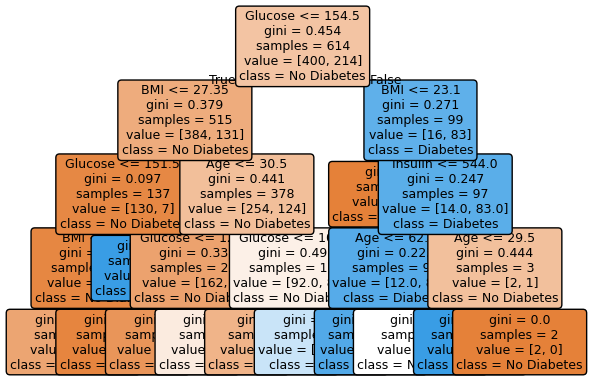

In [27]:
plot_tree(
    tree_clf,
    feature_names=pima_cols[:-1],
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=9
)

Text(0.5, 1.0, '24EU02006-Decision Tree Classifier Structure (Max Depth = 4)')

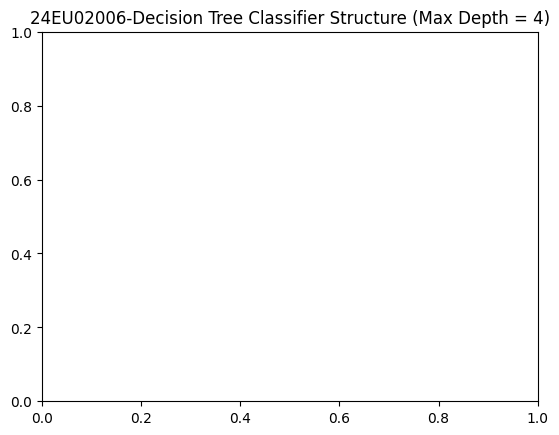

In [28]:
plt.title("24EU02006-Decision Tree Classifier Structure (Max Depth = 4)")

In [29]:
plt.show()

In [30]:
#Subtask 1.4: Constructing a Decision Tree Regressor

In [31]:
from sklearn.tree import DecisionTreeRegressor

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [34]:
boston_df = pd.read_csv(boston_url)

In [35]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [36]:
X_boston = boston_df[boston_features]

In [37]:
y_boston = boston_df['medv']

In [38]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [39]:
scaler_r = StandardScaler()

In [40]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [41]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [42]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [43]:
tree_reg.fit(X_train_r_scaled, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [44]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


In [45]:
#Subtask 1.5: Evaluating Decision Tree Regressor Predictions

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

In [47]:
import numpy as np

In [48]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [49]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [50]:
rmse_val = np.sqrt(mse_val)

In [51]:
r2_val = r2_score(y_test_r, reg_preds)

In [52]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [53]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [54]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



In [55]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

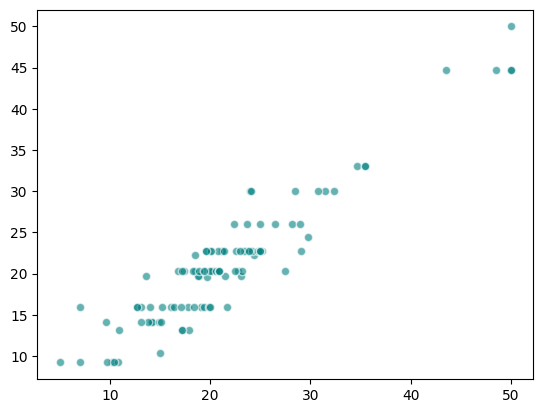

In [56]:
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')

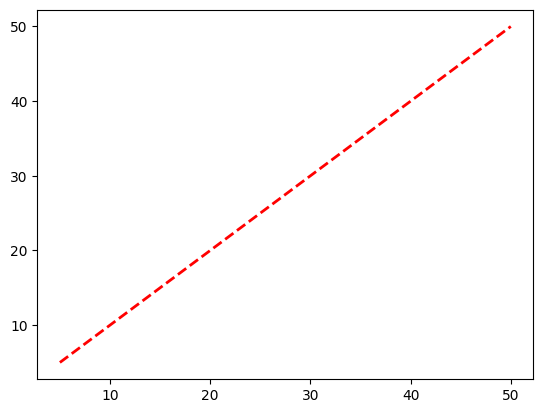

In [57]:
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')

Text(0.5, 1.0, '24EU2006-Decision Tree Regressor: Actual vs. Predicted')

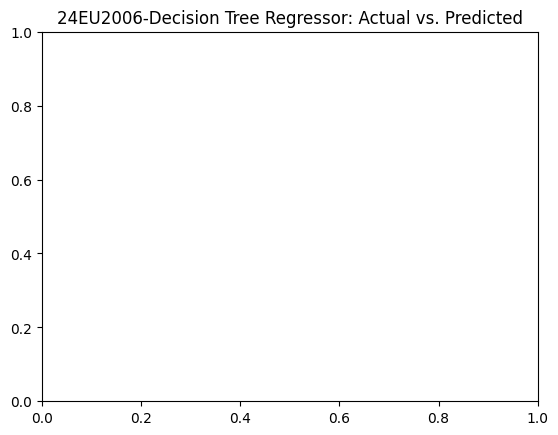

In [58]:
plt.title("24EU2006-Decision Tree Regressor: Actual vs. Predicted")

Text(0.5, 0, 'Actual Home Value (MEDV)')

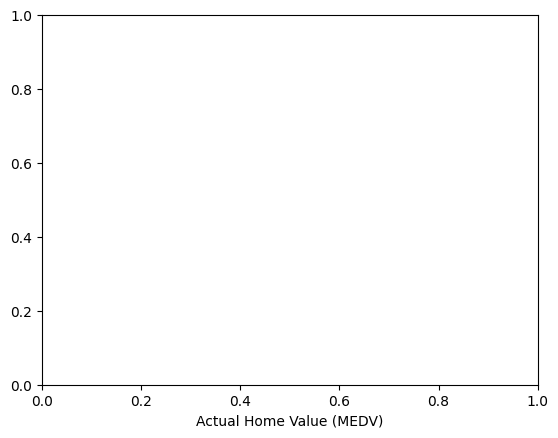

In [59]:
plt.xlabel("Actual Home Value (MEDV)")

Text(0, 0.5, 'Predicted Home Value (MEDV)')

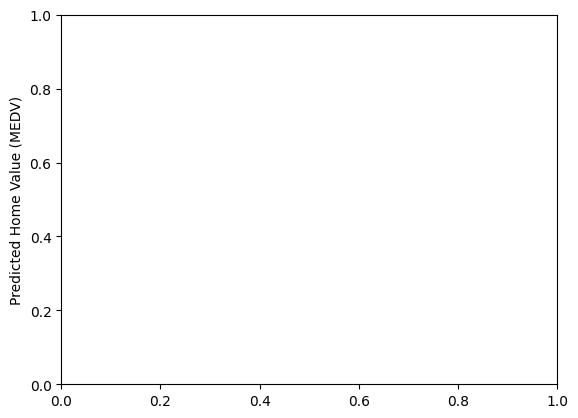

In [60]:
plt.ylabel("Predicted Home Value (MEDV)")

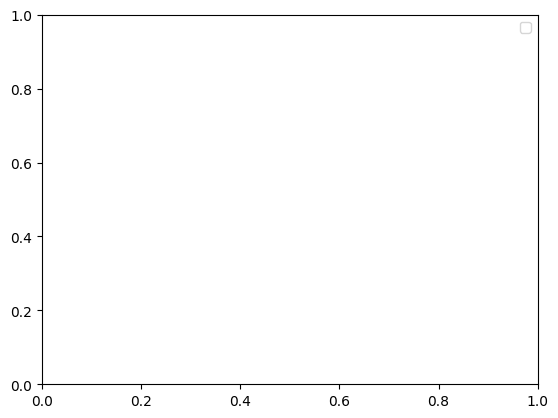

In [61]:
plt.legend()

In [62]:
plt.show()

In [63]:
#Task 2: Develop ensemble learning models using Bagging, Random Forest, and Voting techniques

In [64]:
import warnings

In [65]:
warnings.filterwarnings("ignore")

In [66]:
import pandas as pd

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [70]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [71]:
sonar_columns = sonar_features + ['Class']

In [72]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [73]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [74]:
X_sonar = sonar_df[sonar_features]

In [75]:
y_sonar = sonar_df['Class_numeric']

In [76]:
scaler_sonar = StandardScaler()

In [77]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [78]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [79]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [80]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


In [81]:
#Subtask 2.2: Implementing a Bagging Classifier

In [82]:
from sklearn.ensemble import BaggingClassifier

In [83]:
from sklearn.metrics import accuracy_score

In [84]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [85]:
bagging_model.fit(X_train_s, y_train_s)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [86]:
bagging_preds = bagging_model.predict(X_test_s)

In [87]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [88]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


In [89]:
#Subtask 2.3: Implementing a Random Forest Classifier

In [90]:
from sklearn.ensemble import RandomForestClassifier

In [91]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [92]:
rf_model.fit(X_train_s, y_train_s)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [93]:
rf_preds = rf_model.predict(X_test_s)

In [94]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [95]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


In [96]:
# Subtask 2.4: Implementing a Voting Ensemble Classifier

In [97]:
from sklearn.ensemble import VotingClassifier

In [98]:
from sklearn.linear_model import LogisticRegression

In [99]:
from sklearn.svm import SVC

In [100]:
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [101]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [102]:
voting_model.fit(X_train_s, y_train_s)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=500,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [103]:
voting_preds = voting_model.predict(X_test_s)

In [104]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [105]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


In [106]:
#Subtask 2.5: Performance Comparison of Ensemble Techniques

In [107]:
import matplotlib.pyplot as plt

In [108]:
import seaborn as sns

In [109]:
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [110]:
print("--- Performance Comparison ---")

--- Performance Comparison ---


In [111]:
print(ensemble_results.to_string(index=False))

      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


In [112]:
plt.figure(figsize=(6, 4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='Test Accuracy (%)', ylabel='Ensemble Technique'>

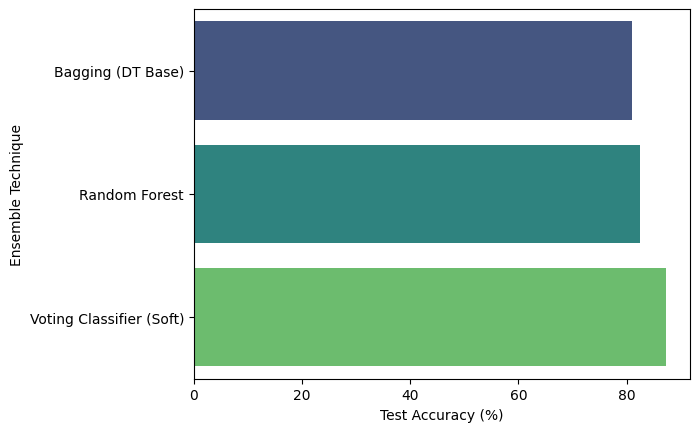

In [113]:
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')

(50.0, 100.0)

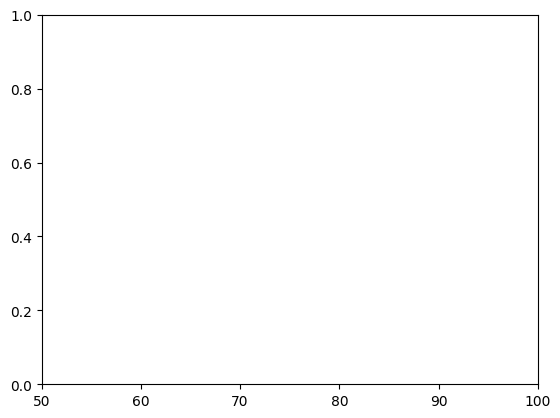

In [114]:
plt.xlim([50, 100])

Text(0.5, 1.0, '24EU02006-Ensemble Models Accuracy Comparison')

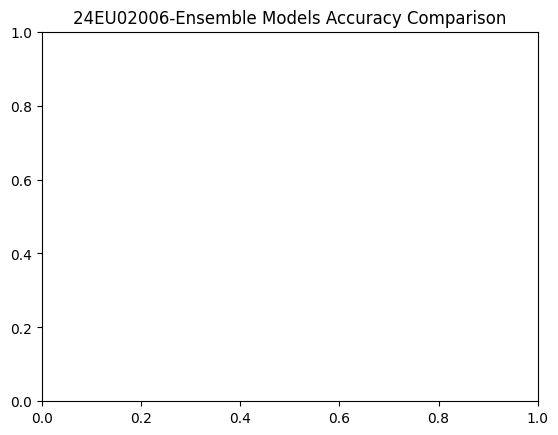

In [115]:
plt.title("24EU02006-Ensemble Models Accuracy Comparison")

In [116]:
plt.show()

In [117]:
#Task 3: Implement and compare boosting techniques including AdaBoost and Gradient Boosting for predictive enhancement

In [118]:
import warnings

In [119]:
warnings.filterwarnings("ignore")

In [120]:
from sklearn.ensemble import AdaBoostClassifier

In [121]:
from sklearn.metrics import accuracy_score

In [122]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [123]:
adaboost_model.fit(X_train_s, y_train_s)

AdaBoostClassifier(random_state=42)

In [124]:
ada_preds = adaboost_model.predict(X_test_s)

In [125]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [126]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 85.71%


In [127]:
#Subtask 3.2: Implementing the Gradient Boosting Classifier

In [128]:
from sklearn.ensemble import GradientBoostingClassifier

In [129]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [130]:
gb_model.fit(X_train_s, y_train_s)

GradientBoostingClassifier(random_state=42)

In [131]:
gb_preds = gb_model.predict(X_test_s)

In [132]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [133]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 80.95%


In [134]:
#Subtask 3.3: Hyperparameter Tuning for Gradient Boosting Classifier

In [135]:
from sklearn.model_selection import GridSearchCV

In [136]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [137]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [138]:
grid_gb.fit(X_train_s, y_train_s)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [139]:
best_gb = grid_gb.best_estimator_

In [140]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [141]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [142]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)

Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


In [143]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 74.60%


In [144]:
#Subtask 3.4: Master Comparison: Ensemble vs. Boosting Models

In [146]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier',
        'Random Forest Classifier',
        'Voting Ensemble (Soft)',
        'AdaBoost Classifier',
        'Base Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100,
        rf_accuracy * 100,
        voting_accuracy * 100,
        ada_accuracy * 100,
        gb_accuracy * 100,
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [147]:
print("--- Master Performance Table: Tasks 2 & 3 ---")

--- Master Performance Table: Tasks 2 & 3 ---


In [148]:
print(master_comparison.to_string(index=False))

        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
     AdaBoost Classifier     85.714286
Random Forest Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     80.952381
 Tuned Gradient Boosting     74.603175


In [149]:
#Subtask 3.5: Plotting Feature Importances (Random Forest vs. Tuned Gradient Boosting)

In [150]:
import matplotlib.pyplot as plt

In [151]:
import numpy as np

In [152]:
rf_importances = rf_model.feature_importances_

In [153]:
gb_importances = best_gb.feature_importances_

In [154]:
top_indices_rf = np.argsort(rf_importances)[-10:]

In [155]:
top_indices_gb = np.argsort(gb_importances)[-10:]

In [156]:
features_list = [f"F_{i}" for i in range(1, 61)]

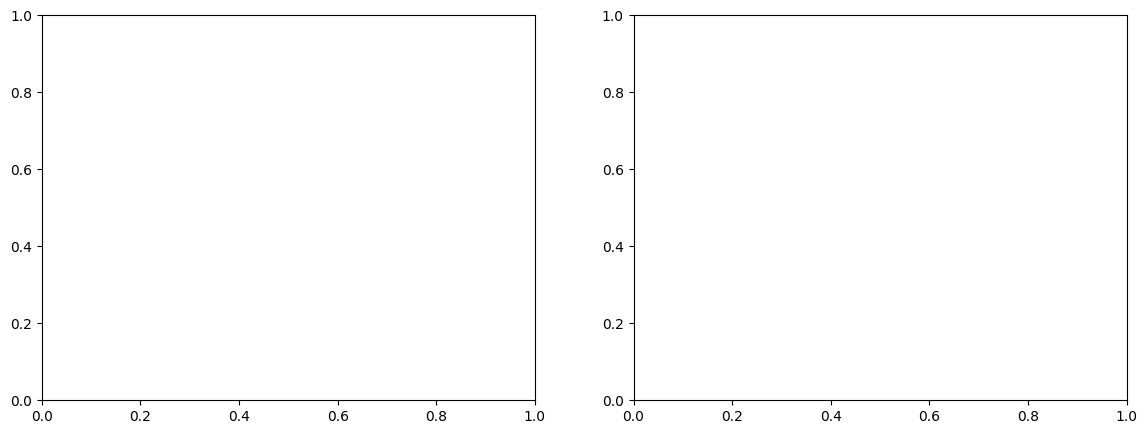

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [158]:
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')

<BarContainer object of 10 artists>

In [159]:
axes[0].set_yticks(range(10))

In [160]:
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])

[Text(0, 0, 'F_1'),
 Text(0, 1, 'F_36'),
 Text(0, 2, 'F_49'),
 Text(0, 3, 'F_52'),
 Text(0, 4, 'F_12'),
 Text(0, 5, 'F_47'),
 Text(0, 6, 'F_48'),
 Text(0, 7, 'F_10'),
 Text(0, 8, 'F_11'),
 Text(0, 9, 'F_9')]

In [162]:
axes[0].set_title("24EU02006-Top 10 Feature Importances: Random Forest")

Text(0.5, 1.0, '24EU02006-Top 10 Feature Importances: Random Forest')

In [163]:
axes[0].set_xlabel("Relative Importance")

Text(0.5, 4.444444444444445, 'Relative Importance')

In [164]:
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')

<BarContainer object of 10 artists>

In [165]:
axes[1].set_yticks(range(10))

In [166]:
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])

[Text(0, 0, 'F_43'),
 Text(0, 1, 'F_21'),
 Text(0, 2, 'F_17'),
 Text(0, 3, 'F_45'),
 Text(0, 4, 'F_47'),
 Text(0, 5, 'F_37'),
 Text(0, 6, 'F_4'),
 Text(0, 7, 'F_28'),
 Text(0, 8, 'F_9'),
 Text(0, 9, 'F_11')]

In [167]:
axes[1].set_title("24EU02006-Top 10 Feature Importances: Tuned Gradient Boosting")

Text(0.5, 1.0, '24EU02006-Top 10 Feature Importances: Tuned Gradient Boosting')

In [168]:
axes[1].set_xlabel("Relative Importance")

Text(0.5, 4.444444444444445, 'Relative Importance')

In [169]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [170]:
plt.show()